In [17]:
# Run once to install everything needed
%pip install torch scikit-learn pandas matplotlib numpy --quiet

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import (
    classification_report, roc_auc_score,
    precision_recall_curve, average_precision_score,
)
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore")
torch.manual_seed(42)
np.random.seed(42)

print(f"PyTorch  : {torch.__version__}")
print(f"Device   : {'CUDA' if torch.cuda.is_available() else 'CPU'}")

PyTorch  : 2.11.0+cpu
Device   : CPU


### Configuration

In [19]:
DATA_PATH = "engineered_network_traffic.csv"   
OUT_DIR   = "outputs"

CFG = dict(
    seq_len       = 30,     # sliding-window length (time steps)
    train_frac    = 0.60,   # fraction used for training (time-ordered)
    hidden_dim    = 64,     # LSTM hidden size
    latent_dim    = 16,     # bottleneck dimension
    num_layers    = 2,      # stacked LSTM layers
    dropout       = 0.2,
    epochs        = 10,
    batch_size    = 128,
    lr            = 1e-3,
    threshold_pct = 99.0,   # percentile for anomaly threshold
)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Config loaded. OUT_DIR:", OUT_DIR)

Config loaded. OUT_DIR: outputs


In [20]:
df_raw = pd.read_csv(DATA_PATH)
print(f"Loaded {len(df_raw):,} rows from {DATA_PATH}")

df_raw.columns = df_raw.columns.str.strip()
for col in df_raw.select_dtypes("object").columns:
    df_raw[col] = df_raw[col].str.strip()

if "Label" in df_raw.columns:
        df_raw["label"] = (df_raw["Label"] != "BENIGN").astype(int)

print(f"Attack rate : {df_raw['label'].mean()*100:.1f}%")
df_raw.head(3)

Loaded 2,830,743 rows from engineered_network_traffic.csv
Attack rate : 19.7%


,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Flow Bytes/s,Flow Packets/s,Fwd Packets/s,Bwd Packets/s,Min Packet Length,...,Flow Duration_rmean,Flow Duration_rstd,Total Fwd Packets_rmean,Total Fwd Packets_rstd,Total Backward Packets_rmean,Total Backward Packets_rstd,Total Length of Fwd Packets_rmean,Total Length of Fwd Packets_rstd,label,Label
0,0.000319,0.000000,0.000003,4.651163e-07,9.153974e-09,0.111921,0.333342,0.000009,0.000013,0.004144,...,0.000319,0.000000,0.000000,0.000000,0.000003,0.000000,4.651163e-07,0.000000,0,BENIGN
1,0.000004,0.000046,0.000017,1.333333e-05,4.973659e-07,0.112367,0.338900,0.007655,0.005219,0.000000,...,0.000162,0.000223,0.000023,0.000032,0.000010,0.000010,6.899225e-06,0.000009,0,BENIGN
2,0.000009,0.000041,0.000021,2.441860e-04,4.805836e-06,0.114388,0.335769,0.003044,0.002740,0.000000,...,0.000111,0.000181,0.000029,0.000025,0.000014,0.000009,8.599483e-05,0.000137,0,BENIGN


In [21]:
def make_sequences(data, seq_len):
    """Sliding window → (N, seq_len, n_features)."""
    return np.array([data[i:i+seq_len] for i in range(len(data)-seq_len+1)],
                    dtype=np.float32)

In [22]:
# Read data 
df_feat = pd.read_csv(DATA_PATH)

# Specify columns for features only.
# This line excludes the timing and label columns to keep the description clutter-free.
FEAT_COLS = [c for c in df_feat.columns if c not in ("label", "Label", "Timestamp")]

# Displaying the matrix size
print(f"Feature matrix : {len(df_feat):,} rows × {len(FEAT_COLS)} columns")

# Display statistics (describe) with rounding to 3 decimal places
df_feat[FEAT_COLS].describe().round(3)

Feature matrix : 2,830,743 rows × 22 columns


,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Flow Bytes/s,Flow Packets/s,Fwd Packets/s,Bwd Packets/s,Min Packet Length,...,Packet Length Std,Destination Port,Flow Duration_rmean,Flow Duration_rstd,Total Fwd Packets_rmean,Total Fwd Packets_rstd,Total Backward Packets_rmean,Total Backward Packets_rstd,Total Length of Fwd Packets_rmean,Total Length of Fwd Packets_rstd
count,2830743.000,2830743.000,2830743.000,2830743.000,2830743.000,2830743.000,2830743.000,2830743.000,2830743.000,2830743.000,...,2830743.000,2830743.000,2830743.000,2830743.000,2830743.000,2830743.000,2830743.000,2830743.000,2830743.0,2830743.000
mean,0.123,0.000,0.000,0.000,0.000,0.113,0.345,0.021,0.003,0.011,...,0.062,0.123,0.123,0.106,0.000,0.000,0.000,0.000,0.0,0.000
std,0.280,0.003,0.003,0.001,0.003,0.011,0.044,0.083,0.019,0.017,...,0.134,0.279,0.220,0.149,0.001,0.003,0.001,0.003,0.0,0.001
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0,0.000
25%,0.000,0.000,0.000,0.000,0.000,0.112,0.333,0.000,0.000,0.000,...,0.000,0.001,0.000,0.000,0.000,0.000,0.000,0.000,0.0,0.000
50%,0.000,0.000,0.000,0.000,0.000,0.112,0.333,0.000,0.000,0.001,...,0.005,0.001,0.015,0.015,0.000,0.000,0.000,0.000,0.0,0.000
75%,0.027,0.000,0.000,0.000,0.000,0.112,0.337,0.004,0.004,0.025,...,0.037,0.007,0.116,0.210,0.000,0.000,0.000,0.000,0.0,0.000
max,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,...,1.000,1.000,0.995,0.527,0.101,0.316,0.101,0.316,0.1,0.316


In [23]:
# ── Train / test split (time-ordered, no shuffle) ─────────────────────────────
X_all = df_feat[FEAT_COLS].values.astype(np.float32)
y_all = df_feat["label"].values
ts_all = df_feat["Timestamp"].values if "Timestamp" in df_feat.columns else None

n_train     = int(len(X_all) * CFG["train_frac"])
X_tr_raw    = X_all[:n_train];  y_tr = y_all[:n_train]
X_te_raw    = X_all[n_train:];  y_te = y_all[n_train:]
X_tr_normal = X_tr_raw[y_tr == 0]   # unsupervised: train on normal only

print(f"Train (normal) : {len(X_tr_normal):,}")
print(f"Test           : {len(X_te_raw):,}  (attacks: {y_te.sum():,})")

# Sliding-window sequences
seq_len   = CFG["seq_len"]
seqs_tr   = make_sequences(X_tr_normal, seq_len)
seqs_te   = make_sequences(X_te_raw,    seq_len)
y_te_seq  = y_te[seq_len-1 : seq_len-1+len(seqs_te)]
ts_te_seq = (ts_all[n_train+seq_len-1 : n_train+seq_len-1+len(seqs_te)]
             if ts_all is not None else None)

print(f"Train sequences : {seqs_tr.shape}  (normal only)")
print(f"Test  sequences : {seqs_te.shape}")


Train (normal) : 1,429,722
Test           : 1,132,298  (attacks: 288,923)
Train sequences : (1429693, 30, 22)  (normal only)
Test  sequences : (1132269, 30, 22)


## LSTM Autoencoder  

Architecture (inspired by Kitsune's unsupervised philosophy):

```
Input (batch, seq_len, n_features)
  └─ Encoder: stacked LSTM → FC → latent z  (batch, latent_dim)
  └─ Decoder: repeat z → stacked LSTM → FC → x̂  (batch, seq_len, n_features)
Loss: MSE(x, x̂)
```


In [24]:
class LSTMEncoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim, num_layers, dropout):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers,
                            batch_first=True,
                            dropout=dropout if num_layers > 1 else 0.0)
        self.fc   = nn.Linear(hidden_dim, latent_dim)

    def forward(self, x):
        _, (hn, _) = self.lstm(x)
        return self.fc(hn[-1])           


class LSTMDecoder(nn.Module):
    def __init__(self, latent_dim, hidden_dim, output_dim, seq_len, num_layers, dropout):
        super().__init__()
        self.seq_len = seq_len
        self.fc      = nn.Linear(latent_dim, hidden_dim)
        self.lstm    = nn.LSTM(hidden_dim, hidden_dim, num_layers,
                               batch_first=True,
                               dropout=dropout if num_layers > 1 else 0.0)
        self.out     = nn.Linear(hidden_dim, output_dim)

    def forward(self, z):
        h0      = torch.tanh(self.fc(z))                          
        dec_in  = h0.unsqueeze(1).repeat(1, self.seq_len, 1)    
        out, _  = self.lstm(dec_in)
        return self.out(out)                                       


class LSTMAutoEncoder(nn.Module):
    """Seq2Seq LSTM autoencoder for unsupervised anomaly detection."""
    def __init__(self, input_dim, hidden_dim, latent_dim, seq_len, num_layers, dropout):
        super().__init__()
        self.encoder = LSTMEncoder(input_dim, hidden_dim, latent_dim, num_layers, dropout)
        self.decoder = LSTMDecoder(latent_dim, hidden_dim, input_dim, seq_len, num_layers, dropout)

    def forward(self, x):
        return self.decoder(self.encoder(x))

    @torch.no_grad()
    def reconstruction_error(self, x_tensor):
        self.eval()
        x_hat = self(x_tensor)
        return ((x_tensor - x_hat) ** 2).mean(dim=(1, 2)).cpu().numpy()


n_feat = X_all.shape[1]
model  = LSTMAutoEncoder(
    input_dim  = n_feat,
    hidden_dim = CFG["hidden_dim"],
    latent_dim = CFG["latent_dim"],
    seq_len    = seq_len,
    num_layers = CFG["num_layers"],
    dropout    = CFG["dropout"],
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"\nTotal parameters: {total_params:,}")

LSTMAutoEncoder(
  (encoder): LSTMEncoder(
    (lstm): LSTM(22, 64, num_layers=2, batch_first=True, dropout=0.2)
    (fc): Linear(in_features=64, out_features=16, bias=True)
  )
  (decoder): LSTMDecoder(
    (fc): Linear(in_features=16, out_features=64, bias=True)
    (lstm): LSTM(64, 64, num_layers=2, batch_first=True, dropout=0.2)
    (out): Linear(in_features=64, out_features=22, bias=True)
  )
)

Total parameters: 125,926


In [25]:
def train(model, train_seqs, cfg, device):
    optimiser = torch.optim.Adam(model.parameters(), lr=cfg["lr"])
    criterion = nn.MSELoss()
    loader    = DataLoader(TensorDataset(torch.tensor(train_seqs)),
                           batch_size=cfg["batch_size"], shuffle=True)
    history   = []
    model.train()

    for epoch in range(1, cfg["epochs"] + 1):
        total = 0.0
        for (batch,) in loader:
            batch = batch.to(device)
            optimiser.zero_grad()
            loss  = criterion(model(batch), batch)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimiser.step()
            total += loss.item() * len(batch)
        avg = total / len(train_seqs)
        history.append(avg)
        if epoch % 5 == 0 or epoch == 1:
            print(f"  Epoch {epoch:3d}/{cfg['epochs']}  loss={avg:.6f}")

    return history


print("Training LSTM autoencoder on NORMAL traffic only …\n")
loss_history = train(model, seqs_tr, CFG, DEVICE)
print("\nDone.")

Training LSTM autoencoder on NORMAL traffic only …

  Epoch   1/10  loss=0.004041
  Epoch   5/10  loss=0.001708
  Epoch  10/10  loss=0.001482

Done.


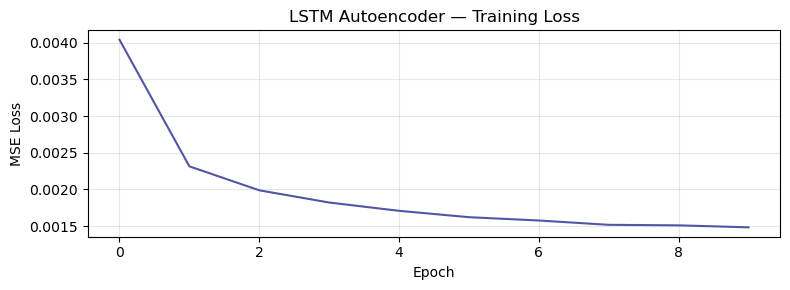

In [27]:
# Training loss curve
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(loss_history, color="#5255A4", lw=1.5)
ax.set(xlabel="Epoch", ylabel="MSE Loss", title="LSTM Autoencoder — Training Loss")
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

In [29]:
def get_lstm_scores_batched(model, sequences, batch_size=512):
    model.eval()
    all_errors = []
    
    dataset = TensorDataset(torch.tensor(sequences, dtype=torch.float32))
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    
    with torch.no_grad():
        for batch in loader:
            x_batch = batch[0].to(DEVICE)
            x_hat = model(x_batch)
            
            error = ((x_batch - x_hat) ** 2).mean(dim=(1, 2)).cpu().numpy()
            all_errors.append(error)
            
    return np.concatenate(all_errors)


print("Calculating test reconstruction errors in batches...")
lstm_scores = get_lstm_scores_batched(model, seqs_te, batch_size=1024)
print(f"Test score range: [{lstm_scores.min():.5f}, {lstm_scores.max():.5f}]")

Calculating test reconstruction errors in batches...
Test score range: [0.00000, 0.03137]


## Visualization

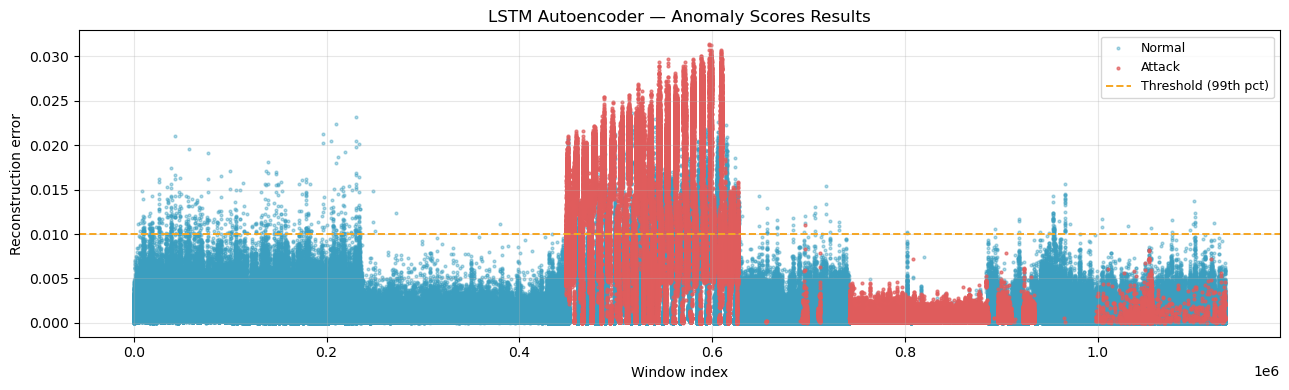

In [32]:
lstm_n = lstm_scores 

seq_len = CFG.get("seq_len", 10) 

if 'y_te_seq' not in locals():
    y_te_seq = (df.iloc[X_test.index]['Label_Encoded'].values)[seq_len-1:]

if 'ts_te_seq' not in locals():
    ts_te_seq = pd.to_datetime(df.iloc[X_test.index]['Time']).values[seq_len-1:]

use_time = (ts_te_seq is not None and 
            pd.api.types.is_datetime64_any_dtype(ts_te_seq))


fig, ax = plt.subplots(figsize=(13, 4))
x = ts_te_seq[:len(lstm_n)] if use_time else np.arange(len(lstm_n))

ax.scatter(x[y_te_seq==0], lstm_n[y_te_seq==0],
           s=4, alpha=0.4, color="#3B9EBF", label="Normal", rasterized=True)

ax.scatter(x[y_te_seq==1], lstm_n[y_te_seq==1],
           s=4, alpha=0.7, color="#E05C5C", label="Attack", rasterized=True)

ax.axhline(threshold_lstm, color="#F5A623", lw=1.4,
           ls="--", label=f"Threshold ({CFG['threshold_pct']:.0f}th pct)")

if use_time:
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    plt.xticks(rotation=30)

ax.set(xlabel="Time" if use_time else "Window index",
       ylabel="Reconstruction error",
       title="LSTM Autoencoder — Anomaly Scores Results")

ax.legend(fontsize=9, loc="upper right")
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

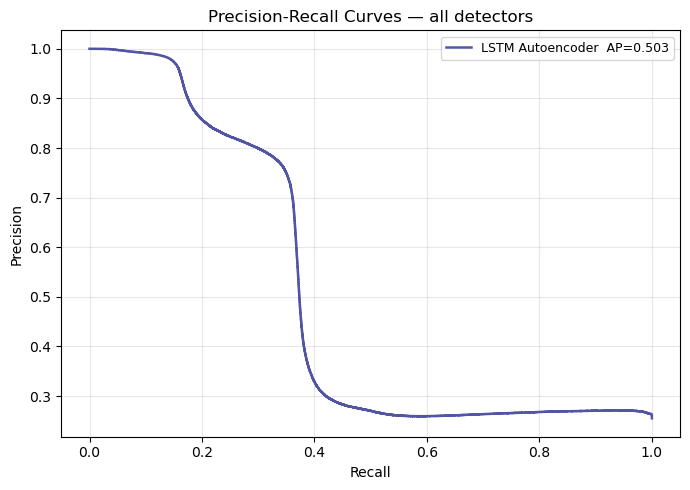

In [36]:
from sklearn.metrics import precision_recall_curve, average_precision_score, roc_auc_score

results = []
results.append({
    "name": "LSTM Autoencoder",
    "scores": lstm_n, # درجات الخطأ التي حسبناها
    "ap": average_precision_score(y_te_seq, lstm_n),
    "auc": roc_auc_score(y_te_seq, lstm_n)
})


colours = ["#5255A4", "#E05C5C", "#3B9EBF"]

fig, ax = plt.subplots(figsize=(7, 5))
for res, col in zip(results, colours):
    p, r, _ = precision_recall_curve(y_te_seq, res["scores"])
    ax.plot(r, p, color=col, lw=1.8, label=f"{res['name']}  AP={res['ap']:.3f}")

ax.set(xlabel="Recall", ylabel="Precision",
       title="Precision-Recall Curves — all detectors")

ax.legend(fontsize=9)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

In [37]:
# ── Summary table ─────────────────────────────────────────────────────────────
summary = pd.DataFrame([
    {"Detector": r["name"], "ROC-AUC": round(r["auc"], 4), "AUPRC": round(r["ap"], 4)}
    for r in results
]).set_index("Detector")

print("\n" + "="*45)
print(" FINAL RESULTS SUMMARY")
print("="*45)
print(summary.to_string())
print("="*45)
summary



 FINAL RESULTS SUMMARY
                  ROC-AUC   AUPRC
Detector                         
LSTM Autoencoder    0.596  0.5032


,ROC-AUC,AUPRC
Detector,,
LSTM Autoencoder,0.596,0.5032


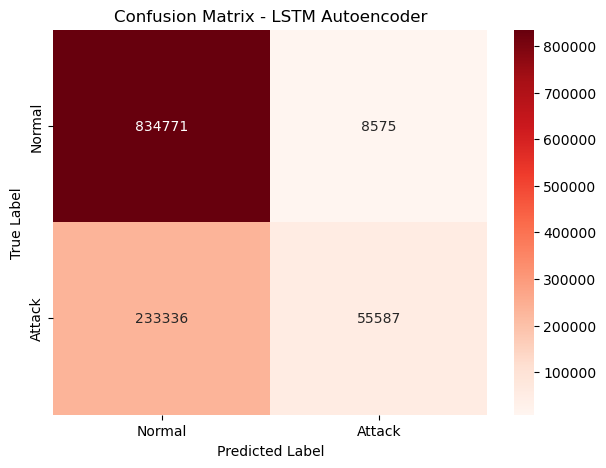


 LSTM AUTOENCODER PERFORMANCE
              precision    recall  f1-score   support

      Normal       0.78      0.99      0.87    843346
      Attack       0.87      0.19      0.31    288923

    accuracy                           0.79   1132269
   macro avg       0.82      0.59      0.59   1132269
weighted avg       0.80      0.79      0.73   1132269



In [38]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_lstm = (lstm_n > threshold_lstm).astype(int)
cm = confusion_matrix(y_te_seq, y_pred_lstm)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Normal', 'Attack'], 
            yticklabels=['Normal', 'Attack'])

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - LSTM Autoencoder')
plt.show()

print("\n" + "="*45)
print(" LSTM AUTOENCODER PERFORMANCE")
print("="*45)
print(classification_report(y_te_seq, y_pred_lstm, target_names=['Normal', 'Attack']))
print("="*45)